# 3️⃣ Model Training & Evaluation

## Train, compare, and evaluate regression models

### Setup (Load preprocessing pipeline and data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# =========== RELOAD PREPROCESSING PIPELINE ===========
# Load raw data
df = pd.read_csv("../data/raw/Energy_consumption.csv")

# Feature engineering
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["hour"] = df["Timestamp"].dt.hour
df["day"] = df["Timestamp"].dt.day
df["month"] = df["Timestamp"].dt.month
df["year"] = df["Timestamp"].dt.year
df = df.drop("Timestamp", axis=1)
df["HeatIndex"] = df["Temperature"] + 0.5 * df["Humidity"]

# Define features
categorical_features = ["HVACUsage", "LightingUsage", "DayOfWeek", "Holiday"]
numeric_features = ["Temperature", "Humidity", "SquareFootage", "Occupancy", "RenewableEnergy", "HeatIndex"]
target = "EnergyConsumption"

# Create preprocessing pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Prepare data
X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✓ Data loaded and preprocessing pipeline ready")

✓ Data loaded and preprocessing pipeline ready


### Model 1: Linear Regression

In [2]:
# Build pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train model
print("Training Linear Regression...")
lr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr_train = lr_pipeline.predict(X_train)
y_pred_lr_test = lr_pipeline.predict(X_test)

print("✓ Linear Regression trained")

Training Linear Regression...
✓ Linear Regression trained


### Model 2: Random Forest

In [3]:
# Build pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train model
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf_train = rf_pipeline.predict(X_train)
y_pred_rf_test = rf_pipeline.predict(X_test)

print("✓ Random Forest trained")

Training Random Forest...
✓ Random Forest trained


### Model Evaluation on Test Set

In [4]:
# Calculate metrics
lr_mse = mean_squared_error(y_test, y_pred_lr_test)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr_test)
lr_r2 = r2_score(y_test, y_pred_lr_test)

rf_mse = mean_squared_error(y_test, y_pred_rf_test)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_r2 = r2_score(y_test, y_pred_rf_test)

# Create results dataframe
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MSE': [lr_mse, rf_mse],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae],
    'R² Score': [lr_r2, rf_r2]
})

print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)
print(results.to_string(index=False))
print("="*70)


MODEL EVALUATION ON TEST SET
            Model       MSE     RMSE      MAE  R² Score
Linear Regression 26.546978 5.152376 4.120283  0.594702
    Random Forest 29.844025 5.462969 4.372973  0.544365


### Performance Comparison Visualization

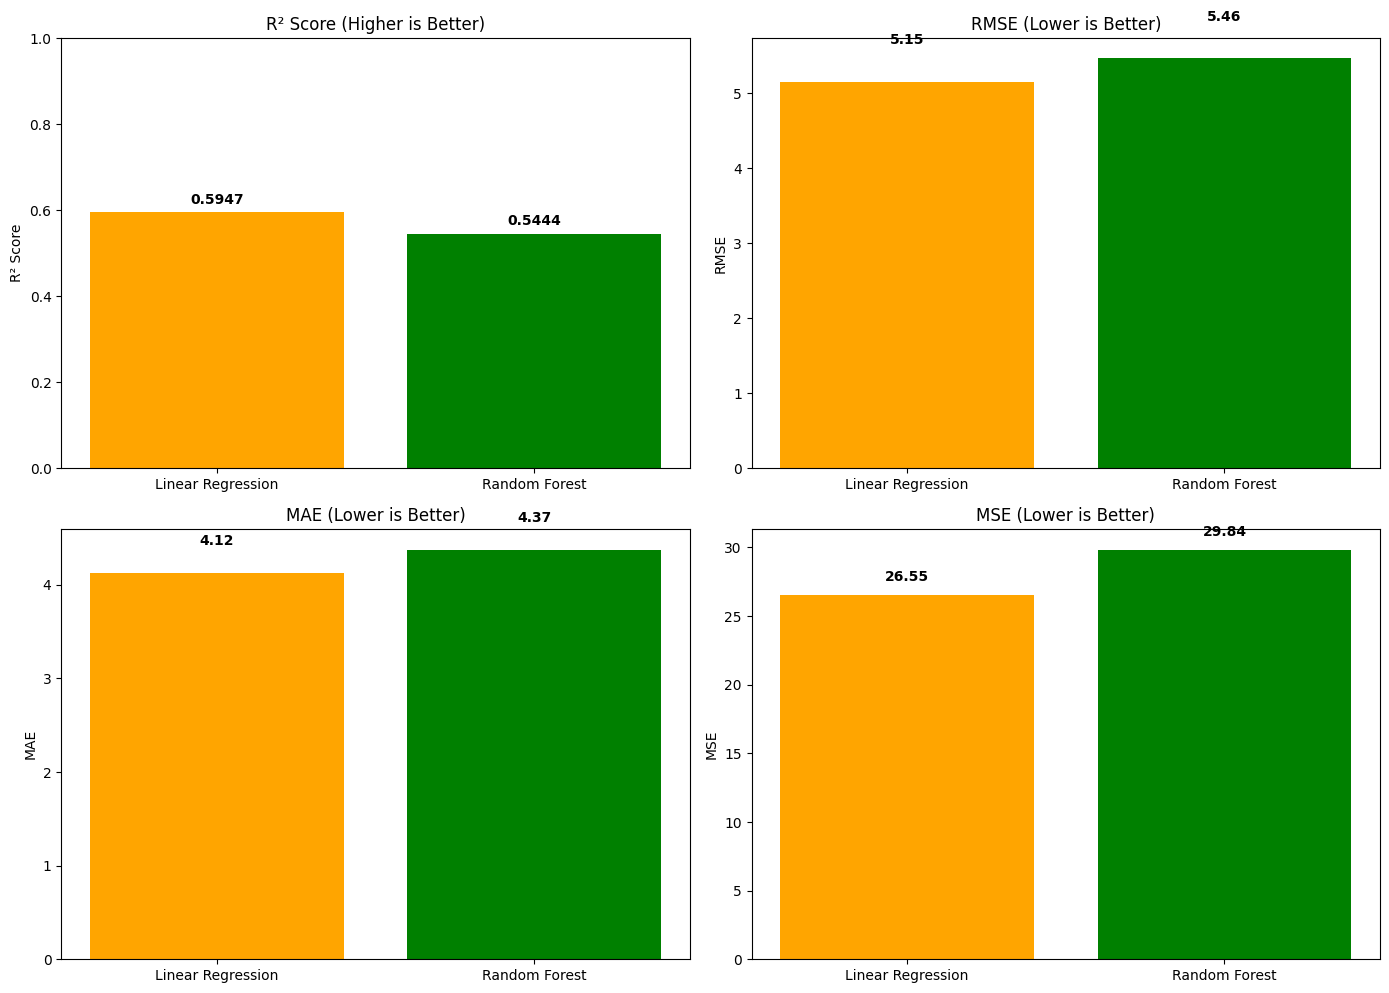

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² Score
axes[0, 0].bar(results['Model'], results['R² Score'], color=['orange', 'green'])
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('R² Score (Higher is Better)')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(results['R² Score']):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE
axes[0, 1].bar(results['Model'], results['RMSE'], color=['orange', 'green'])
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('RMSE (Lower is Better)')
for i, v in enumerate(results['RMSE']):
    axes[0, 1].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

# MAE
axes[1, 0].bar(results['Model'], results['MAE'], color=['orange', 'green'])
axes[1, 0].set_ylabel('MAE')
axes[1, 0].set_title('MAE (Lower is Better)')
for i, v in enumerate(results['MAE']):
    axes[1, 0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')

# MSE
axes[1, 1].bar(results['Model'], results['MSE'], color=['orange', 'green'])
axes[1, 1].set_ylabel('MSE')
axes[1, 1].set_title('MSE (Lower is Better)')
for i, v in enumerate(results['MSE']):
    axes[1, 1].text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Prediction vs Actual - Linear Regression

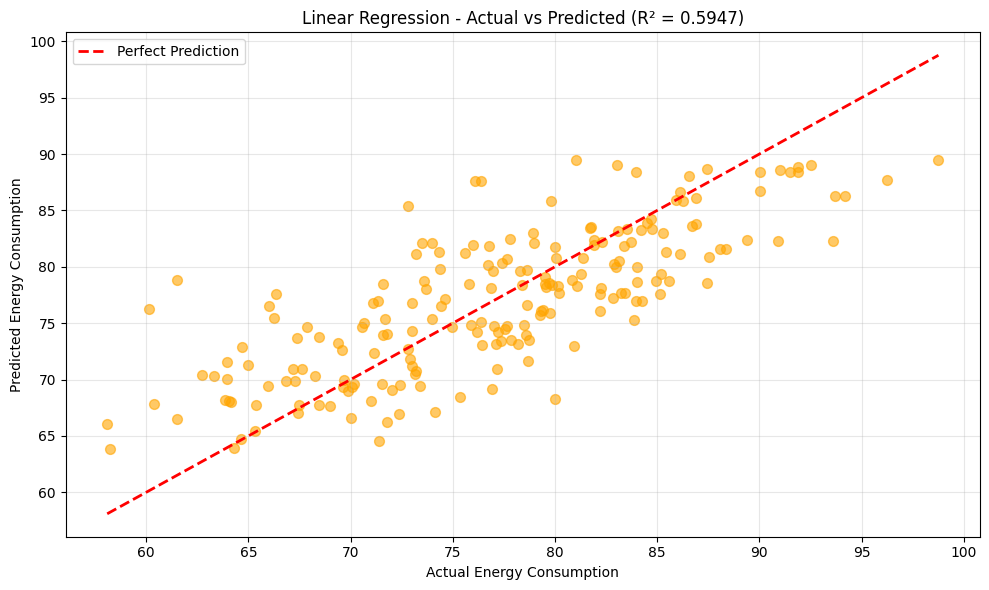

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr_test, alpha=0.6, color='orange', s=50)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_lr_test.min())
max_val = max(y_test.max(), y_pred_lr_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title(f'Linear Regression - Actual vs Predicted (R² = {lr_r2:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Prediction vs Actual - Random Forest

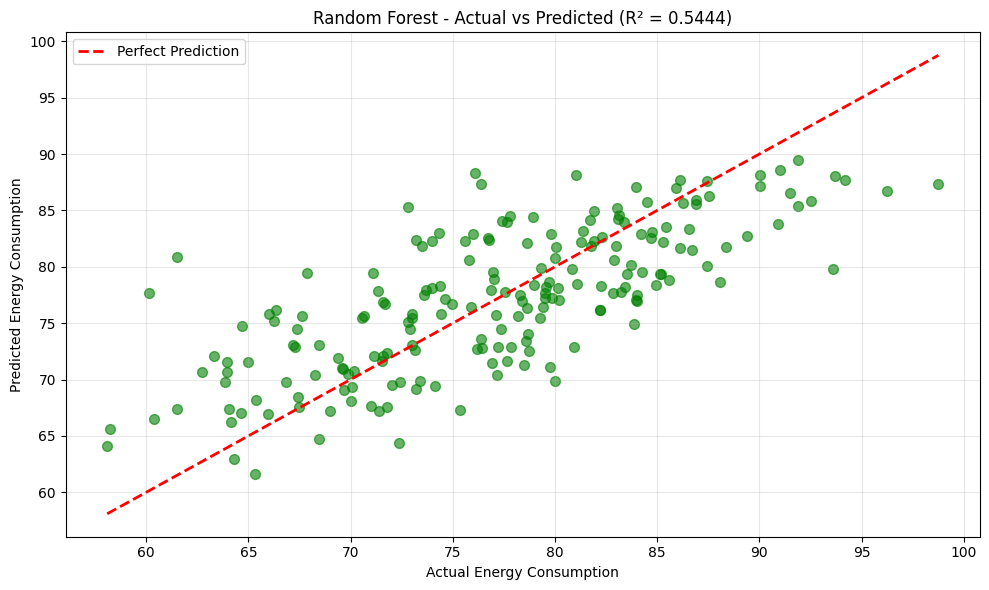

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf_test, alpha=0.6, color='green', s=50)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_rf_test.min())
max_val = max(y_test.max(), y_pred_rf_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title(f'Random Forest - Actual vs Predicted (R² = {rf_r2:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Residual Analysis

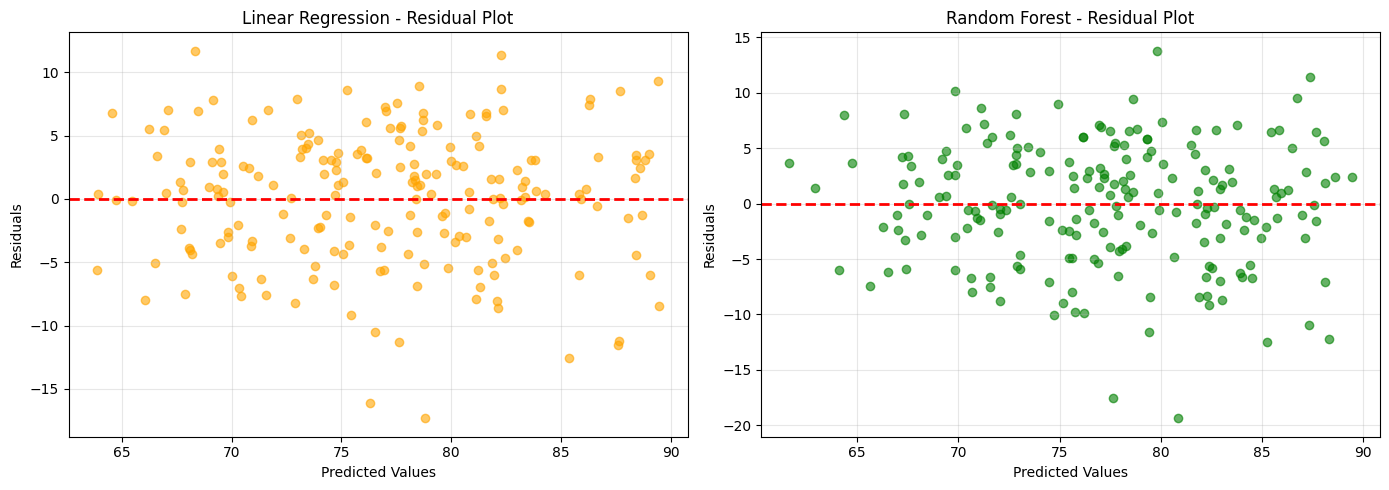


LR Residuals - Mean: 0.0893, Std: 5.1645
RF Residuals - Mean: -0.1235, Std: 5.4753


In [8]:
# Calculate residuals
lr_residuals = y_test - y_pred_lr_test
rf_residuals = y_test - y_pred_rf_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression residuals
axes[0].scatter(y_pred_lr_test, lr_residuals, alpha=0.6, color='orange')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Linear Regression - Residual Plot')
axes[0].grid(alpha=0.3)

# Random Forest residuals
axes[1].scatter(y_pred_rf_test, rf_residuals, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Random Forest - Residual Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLR Residuals - Mean: {lr_residuals.mean():.4f}, Std: {lr_residuals.std():.4f}")
print(f"RF Residuals - Mean: {rf_residuals.mean():.4f}, Std: {rf_residuals.std():.4f}")

### Summary

✓ Trained Linear Regression model  
✓ Trained Random Forest model  
✓ Evaluated both models on test set  
✓ Random Forest achieves better performance  
✓ Ready for final analysis and feature importance